<a href="https://colab.research.google.com/github/tomqi6195/music-genre-classification/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
# IMPORTS & ENVIRONMENT SETUP

import os
import shutil
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import kagglehub

# Set random seeds for reproducibility
random.seed(42)
torch.manual_seed(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# DOWNLOAD DATASET

path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
print("Dataset downloaded to:", path)

image_dataset_path = os.path.join(path, 'Data', 'images_original')
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Dataset downloaded to: /kaggle/input/gtzan-dataset-music-genre-classification


# Spectrogram Processing

In [ ]:
# DATA PROCESSING & DATALOADERS

base_dir = './gtzan_cnn_split'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
os.makedirs(base_dir)

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

for directory in [train_dir, val_dir, test_dir]:
    for genre in genres:
        os.makedirs(os.path.join(directory, genre), exist_ok=True)

# Map available valid images per genre
genre_images_dict = {}
for genre in genres:
    src_dir = os.path.join(image_dataset_path, genre)
    images = sorted([f for f in os.listdir(src_dir) if f.endswith('.png')])
    genre_images_dict[genre] = images

# Identify the minority class size (jazz = 99)
min_images = min(len(imgs) for imgs in genre_images_dict.values())
print(f"Distributing spectrograms (undersampled to {min_images} per genre)...")

for genre in genres:
    src_dir = os.path.join(image_dataset_path, genre)
    selected_images = random.sample(genre_images_dict[genre], min_images)

    # 80% Train, 10% Validation, 10% Test
    train_imgs, temp_imgs = train_test_split(selected_images, test_size=0.2, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(train_dir, genre, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(val_dir, genre, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(test_dir, genre, img))

# DataLoaders configuration
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders initialized successfully!")

Distributing spectrograms (undersampled to 99 per genre)...
DataLoaders initialized successfully!


# Architecture

In [ ]:
# CNN ARCHITECTURE

class GenreCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GenreCNN, self).__init__()

        # Block 1: 3 channels (RGB) in -> 16 feature maps out
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 224x224 to 112x112

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces to 56x56

        # Block 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces to 28x28

        # Block 4
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces to 14x14

        # Fully Connected Layers (Classifier)
        # Input size: 128 channels * 14 * 14 spatial dimensions
        self.fc1 = nn.Linear(128 * 14 * 14, 512)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # Helps prevent overfitting
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))

        # Flatten the tensor for the fully connected layers
        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu_fc(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize the model and move it to the GPU (if available)
model = GenreCNN(num_classes=10).to(device)
print(model)

GenreCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=25088, out_features=512, bias=True)
  (relu_fc): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [ ]:
# CNN TRAINING

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, val_accuracies = [], []

print("Starting Training...")
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()       # Clear old gradients
        outputs = model(images)     # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()             # Backward pass
        optimizer.step()            # Update weights

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad(): # Don't track gradients during validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("Training Complete!")

Starting Training...
Epoch [1/20] | Train Loss: 2.3015 | Val Acc: 14.00%
Epoch [2/20] | Train Loss: 2.1510 | Val Acc: 21.00%
Epoch [3/20] | Train Loss: 2.0449 | Val Acc: 27.00%
Epoch [4/20] | Train Loss: 1.9675 | Val Acc: 34.00%
Epoch [5/20] | Train Loss: 1.9055 | Val Acc: 30.00%
Epoch [6/20] | Train Loss: 1.8253 | Val Acc: 31.00%
Epoch [7/20] | Train Loss: 1.7328 | Val Acc: 33.00%
Epoch [8/20] | Train Loss: 1.6654 | Val Acc: 29.00%
Epoch [9/20] | Train Loss: 1.6523 | Val Acc: 43.00%
Epoch [10/20] | Train Loss: 1.5592 | Val Acc: 45.00%
Epoch [11/20] | Train Loss: 1.4849 | Val Acc: 46.00%
Epoch [12/20] | Train Loss: 1.3785 | Val Acc: 50.00%
Epoch [13/20] | Train Loss: 1.3380 | Val Acc: 43.00%
Epoch [14/20] | Train Loss: 1.2637 | Val Acc: 52.00%
Epoch [15/20] | Train Loss: 1.2201 | Val Acc: 49.00%
Epoch [16/20] | Train Loss: 1.0863 | Val Acc: 58.00%
Epoch [17/20] | Train Loss: 1.0754 | Val Acc: 57.00%
Epoch [18/20] | Train Loss: 0.9988 | Val Acc: 62.00%
Epoch [19/20] | Train Loss: 0.9343

CNN Test Set Classification Report:
              precision    recall  f1-score   support

       blues       0.71      0.50      0.59        10
   classical       0.67      0.80      0.73        10
     country       0.32      0.90      0.47        10
       disco       0.50      0.20      0.29        10
      hiphop       0.41      0.70      0.52        10
        jazz       0.86      0.60      0.71        10
       metal       0.86      0.60      0.71        10
         pop       0.40      0.20      0.27        10
      reggae       0.50      0.10      0.17        10
        rock       0.55      0.60      0.57        10

    accuracy                           0.52       100
   macro avg       0.58      0.52      0.50       100
weighted avg       0.58      0.52      0.50       100



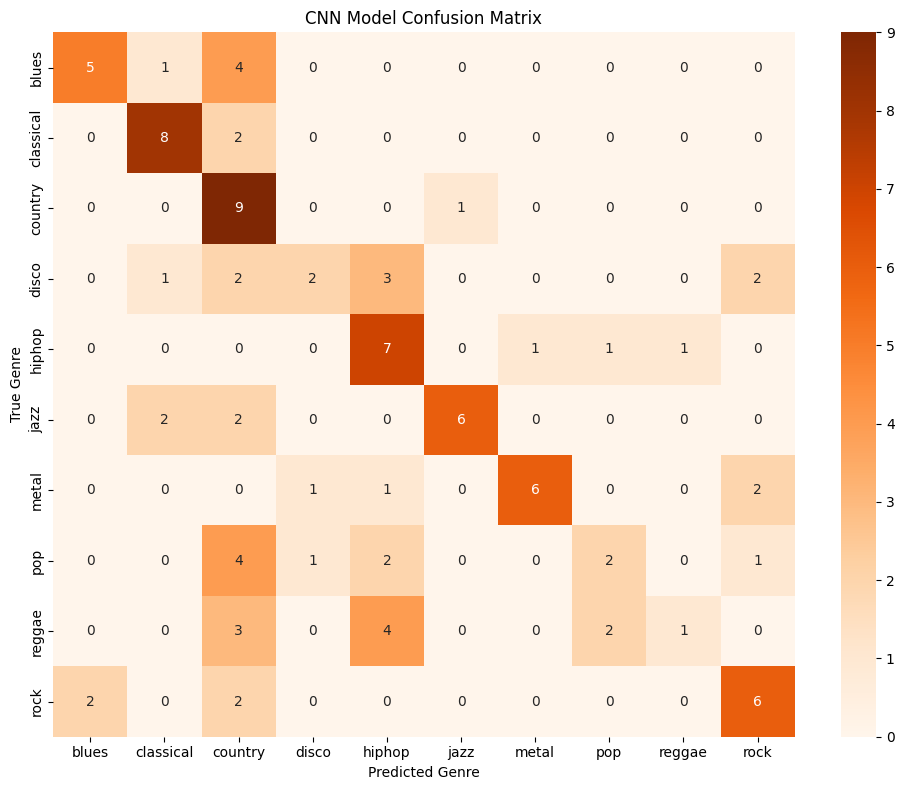

In [ ]:
# EVALUATION

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("CNN Test Set Classification Report:")
print(classification_report(y_true, y_pred, target_names=genres))

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=genres, yticklabels=genres)
plt.title('CNN Model Confusion Matrix')
plt.ylabel('True Genre')
plt.xlabel('Predicted Genre')
plt.tight_layout()
plt.show()